# Weather Trend Forecasting

**Author:** Valeria Mora  
**Date:** May 2026  

## PM Accelerator Mission
By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders. This is the PM Accelerator motto, as we grant aspiring and experienced PMs what they need most – Access. We introduce you to industry leaders, surround you with the right PM ecosystem, and discover the new world of AI product management skills.

## 1. Libraries & Dataset Loading

This analysis uses industry-standard Python libraries for data manipulation, visualization, and machine learning. The Global Weather Repository dataset contains daily weather observations from cities around the world with over 40 meteorological features.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Dataset Overview

The Global Weather Repository dataset provides comprehensive meteorological data collected daily from weather stations worldwide. This section loads and displays the basic structure of the dataset.

In [30]:
df = pd.read_csv('GlobalWeatherRepository.csv')

print(f'\nDataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  • {col}')
display(df.head())


Dataset dimensions: 140923 rows × 41 columns

Column names:
  • country
  • location_name
  • latitude
  • longitude
  • timezone
  • last_updated_epoch
  • last_updated
  • temperature_celsius
  • temperature_fahrenheit
  • condition_text
  • wind_mph
  • wind_kph
  • wind_degree
  • wind_direction
  • pressure_mb
  • pressure_in
  • precip_mm
  • precip_in
  • humidity
  • cloud
  • feels_like_celsius
  • feels_like_fahrenheit
  • visibility_km
  • visibility_miles
  • uv_index
  • gust_mph
  • gust_kph
  • air_quality_Carbon_Monoxide
  • air_quality_Ozone
  • air_quality_Nitrogen_dioxide
  • air_quality_Sulphur_dioxide
  • air_quality_PM2.5
  • air_quality_PM10
  • air_quality_us-epa-index
  • air_quality_gb-defra-index
  • sunrise
  • sunset
  • moonrise
  • moonset
  • moon_phase
  • moon_illumination


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## 3. Data Cleaning & Quality Assessment

Data quality is essential for accurate analysis and forecasting. This section assesses missing values, data types, and basic statistical properties of the dataset.

In [31]:
print('='*60)
print('GENERAL DATASET INFORMATION')
print('='*60)
df.info()

print('\n' + '='*60)
print('MISSING VALUES BY COLUMN')
print('='*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
})
cols_con_faltantes = missing_df[missing_df['Missing Count'] > 0]
if len(cols_con_faltantes) > 0:
    print(cols_con_faltantes)
else:
    print('No missing values detected in the dataset')

print('\n' + '='*60)
print('STATISTICAL SUMMARY')
print('='*60)
print(df.describe().round(2))

GENERAL DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 140923 entries, 0 to 140922
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       140923 non-null  str    
 1   location_name                 140923 non-null  str    
 2   latitude                      140923 non-null  float64
 3   longitude                     140923 non-null  float64
 4   timezone                      140923 non-null  str    
 5   last_updated_epoch            140923 non-null  int64  
 6   last_updated                  140923 non-null  str    
 7   temperature_celsius           140923 non-null  float64
 8   temperature_fahrenheit        140923 non-null  float64
 9   condition_text                140923 non-null  str    
 10  wind_mph                      140923 non-null  float64
 11  wind_kph                      140923 non-null  float64
 12  wind_degree                

## 4. Data Preprocessing

Data preprocessing prepares the raw data for analysis by converting date formats, extracting temporal features, and handling missing values through median imputation.

In [32]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['day_of_year'] = df['last_updated'].dt.day_of_year
df['month_name'] = df['last_updated'].dt.strftime('%B')

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

remaining_missing = df.isnull().sum().sum()
print(f'Data preprocessing completed')
print(f'Remaining missing values: {remaining_missing}')
print(f'Total rows: {len(df)}')
print(f'Date range: {df["last_updated"].min().date()} to {df["last_updated"].max().date()}')
print(f'Temperature range: {df["temperature_celsius"].min():.1f}°C to {df["temperature_celsius"].max():.1f}°C')

Data preprocessing completed
Remaining missing values: 0
Total rows: 140923
Date range: 2024-05-16 to 2026-05-12
Temperature range: -29.8°C to 79.3°C


## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) reveals patterns, trends, and relationships in the weather data. The following visualizations show global temperature distributions, monthly patterns, and relationships between key meteorological variables.

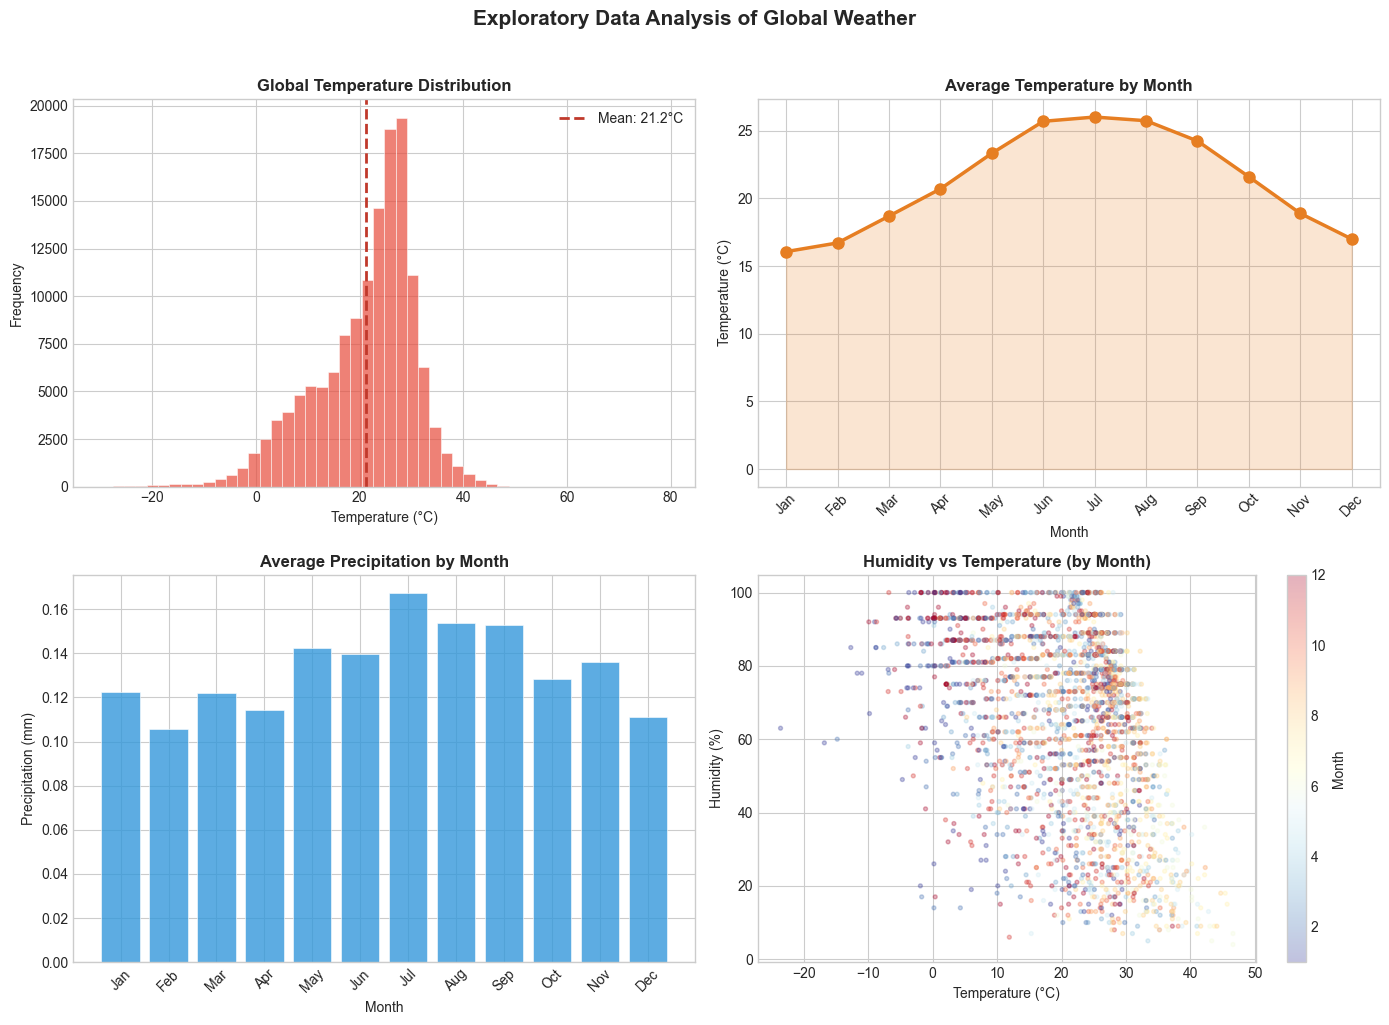

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis of Global Weather',
             fontsize=15, fontweight='bold', y=1.02)

axes[0, 0].hist(df['temperature_celsius'], bins=50,
                color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Global Temperature Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['temperature_celsius'].mean(), color='#c0392b',
                   linestyle='--', linewidth=2, label=f"Mean: {df['temperature_celsius'].mean():.1f}°C")
axes[0, 0].legend()

temp_monthly = df.groupby('month')['temperature_celsius'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].plot(temp_monthly.index, temp_monthly.values,
               marker='o', color='#e67e22', linewidth=2.5, markersize=8)
axes[0, 1].fill_between(temp_monthly.index, temp_monthly.values, alpha=0.2, color='#e67e22')
axes[0, 1].set_title('Average Temperature by Month', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(months, rotation=45)

precip_monthly = df.groupby('month')['precip_mm'].mean()
axes[1, 0].bar(precip_monthly.index, precip_monthly.values,
              color='#3498db', alpha=0.8, edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('Average Precipitation by Month', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Precipitation (mm)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(months, rotation=45)

sample = df.sample(min(3000, len(df)), random_state=42)
scatter = axes[1, 1].scatter(sample['temperature_celsius'], sample['humidity'],
                             alpha=0.3, s=8, c=sample['month'], cmap='RdYlBu_r')
axes[1, 1].set_title('Humidity vs Temperature (by Month)', fontweight='bold')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Humidity (%)')
plt.colorbar(scatter, ax=axes[1, 1], label='Month')

plt.tight_layout()
plt.show()

### Correlation Analysis

Correlation analysis identifies relationships between different meteorological variables. Values close to 1 indicate strong positive correlation, while values close to -1 indicate strong negative correlation.

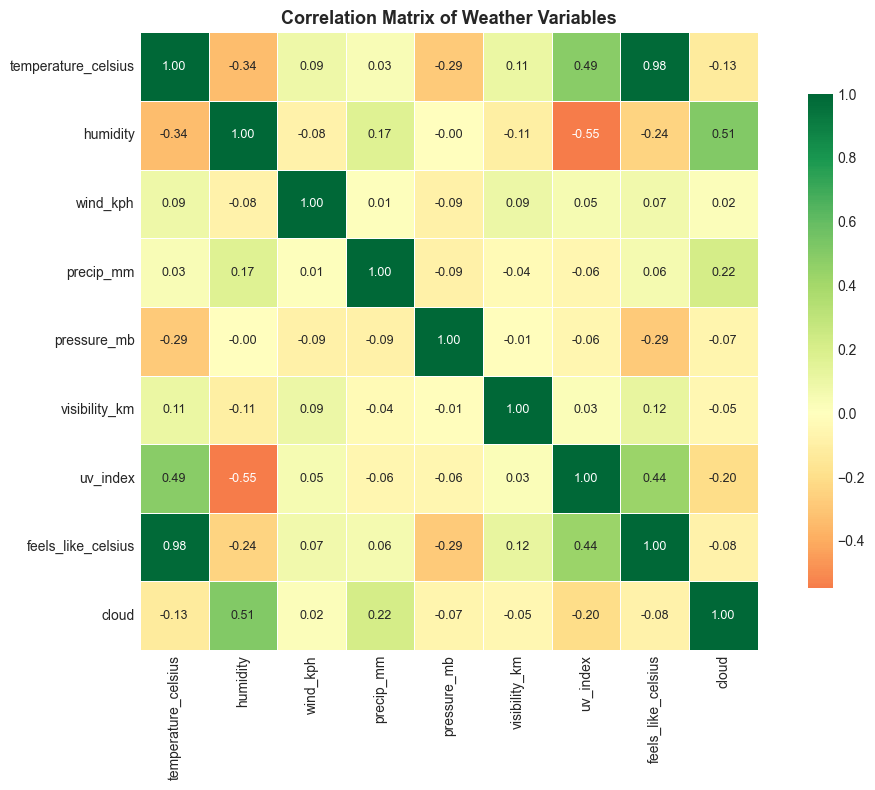


Strongest Correlations with Temperature:
  ↑ feels_like_celsius: 0.984
  ↑ uv_index: 0.490
  ↓ humidity: -0.339
  ↓ pressure_mb: -0.288
  ↓ cloud: -0.129
  ↑ visibility_km: 0.109
  ↑ wind_kph: 0.091
  ↑ precip_mm: 0.034


In [34]:
cols_corr = [
    'temperature_celsius', 'humidity', 'wind_kph',
    'precip_mm', 'pressure_mb', 'visibility_km',
    'uv_index', 'feels_like_celsius', 'cloud'
]
cols_available = [c for c in cols_corr if c in df.columns]

correlation_matrix = df[cols_available].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)
plt.title('Correlation Matrix of Weather Variables',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nStrongest Correlations with Temperature:')
temp_corr = correlation_matrix['temperature_celsius'].abs().sort_values(ascending=False)
for col, val in temp_corr.items():
    if col != 'temperature_celsius':
        direction = '↑' if correlation_matrix['temperature_celsius'][col] > 0 else '↓'
        print(f'  {direction} {col}: {correlation_matrix["temperature_celsius"][col]:.3f}')

## 6. Predictive Model Development

This section builds and evaluates machine learning models to forecast temperature based on weather features. Two models are compared: Linear Regression (baseline) and Random Forest (advanced).

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_real, y_pred):
    """Calculate and display model evaluation metrics"""
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f'\n{"-"*40}')
    print(f'Model: {name}')
    print(f'{"-"*40}')
    print(f'MAE  (Mean Absolute Error):      {mae:.2f}°C')
    print(f'RMSE (Root Mean Squared Error):  {rmse:.2f}°C')
    print(f'R²   (Coefficient of Determination): {r2:.4f} ({r2*100:.1f}%)')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [36]:
features = ['humidity', 'wind_kph', 'precip_mm', 'pressure_mb',
            'visibility_km', 'uv_index', 'month', 'day_of_year']

features_available = [f for f in features if f in df.columns]
target = 'temperature_celsius'

model_df = df[features_available + [target]].dropna()

X = model_df[features_available]
y = model_df[target]

print(f'Input features: {features_available}')
print(f'Target variable: {target}')
print(f'Available records for modeling: {len(model_df)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nTraining set: {len(X_train)} records (80%)')
print(f'Test set: {len(X_test)} records (20%)')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nTraining Linear Regression...')
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print('Linear Regression training completed')

print('\nTraining Random Forest (this may take 1-2 minutes)...')
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print('Random Forest training completed')

print('\n' + '='*50)
print('MODEL EVALUATION RESULTS')
print('='*50)
metrics_lr = evaluate_model('Linear Regression', y_test, lr_pred)
metrics_rf = evaluate_model('Random Forest', y_test, rf_pred)

best_model = 'Random Forest' if metrics_rf['R2'] > metrics_lr['R2'] else 'Linear Regression'
print(f'\nBest performing model: {best_model}')

Input features: ['humidity', 'wind_kph', 'precip_mm', 'pressure_mb', 'visibility_km', 'uv_index', 'month', 'day_of_year']
Target variable: temperature_celsius
Available records for modeling: 140923

Training set: 112738 records (80%)
Test set: 28185 records (20%)

Training Linear Regression...
Linear Regression training completed

Training Random Forest (this may take 1-2 minutes)...
Random Forest training completed

MODEL EVALUATION RESULTS

----------------------------------------
Model: Linear Regression
----------------------------------------
MAE  (Mean Absolute Error):      6.04°C
RMSE (Root Mean Squared Error):  8.31°C
R²   (Coefficient of Determination): 0.2563 (25.6%)

----------------------------------------
Model: Random Forest
----------------------------------------
MAE  (Mean Absolute Error):      3.00°C
RMSE (Root Mean Squared Error):  4.54°C
R²   (Coefficient of Determination): 0.7775 (77.7%)

Best performing model: Random Forest


### Model Predictions Visualization

Comparing actual vs predicted temperature values shows how well each model performs. Points closer to the diagonal line indicate more accurate predictions.

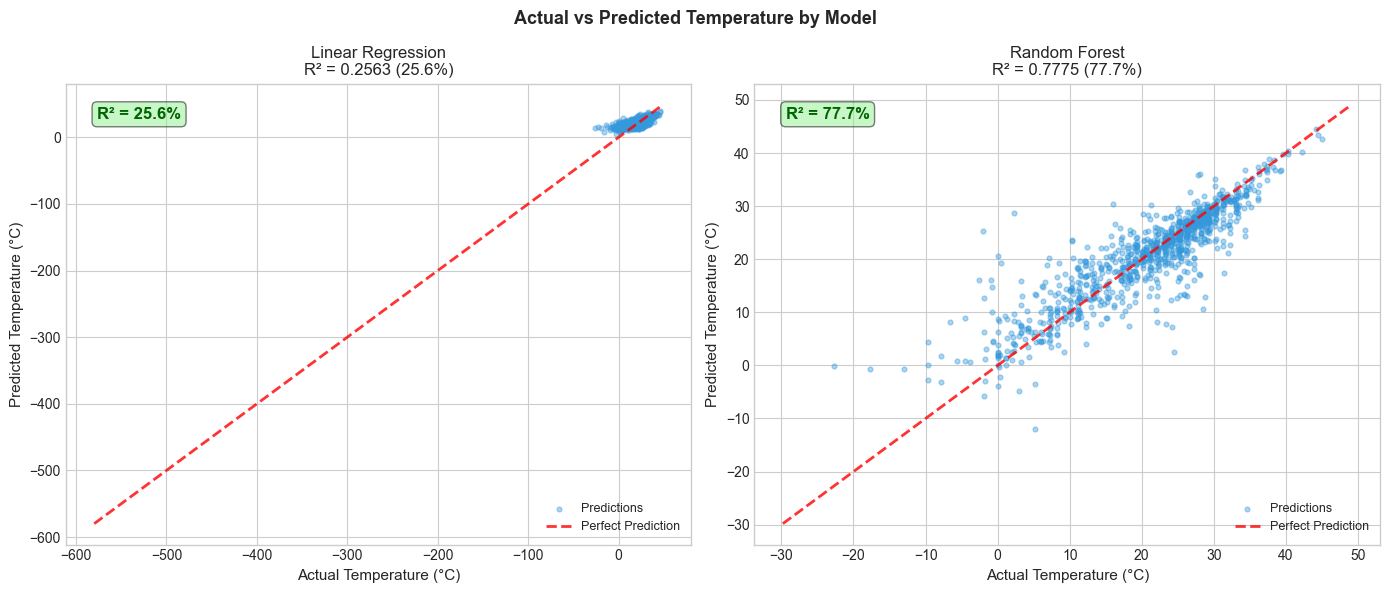

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted Temperature by Model',
             fontsize=13, fontweight='bold')

for ax, model_name, pred, r2 in zip(
    axes,
    ['Linear Regression', 'Random Forest'],
    [lr_pred, rf_pred],
    [metrics_lr['R2'], metrics_rf['R2']]
):
    sample_idx = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)
    y_test_arr = np.array(y_test)

    ax.scatter(y_test_arr[sample_idx], pred[sample_idx],
               alpha=0.4, s=12, color='#3498db', label='Predictions')

    mn = min(y_test_arr.min(), pred.min())
    mx = max(y_test_arr.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction', alpha=0.8)

    ax.set_xlabel('Actual Temperature (°C)', fontsize=11)
    ax.set_ylabel('Predicted Temperature (°C)', fontsize=11)
    ax.set_title(f'{model_name}\nR² = {r2:.4f} ({r2*100:.1f}%)', fontsize=12)
    ax.legend(fontsize=9)
    ax.text(0.05, 0.95, f'R² = {r2*100:.1f}%', transform=ax.transAxes,
            fontsize=12, fontweight='bold', color='darkgreen',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Feature Importance & Time Series Analysis

Feature importance reveals which weather variables have the greatest influence on temperature predictions. Time series analysis shows how global average temperature evolves over the study period.

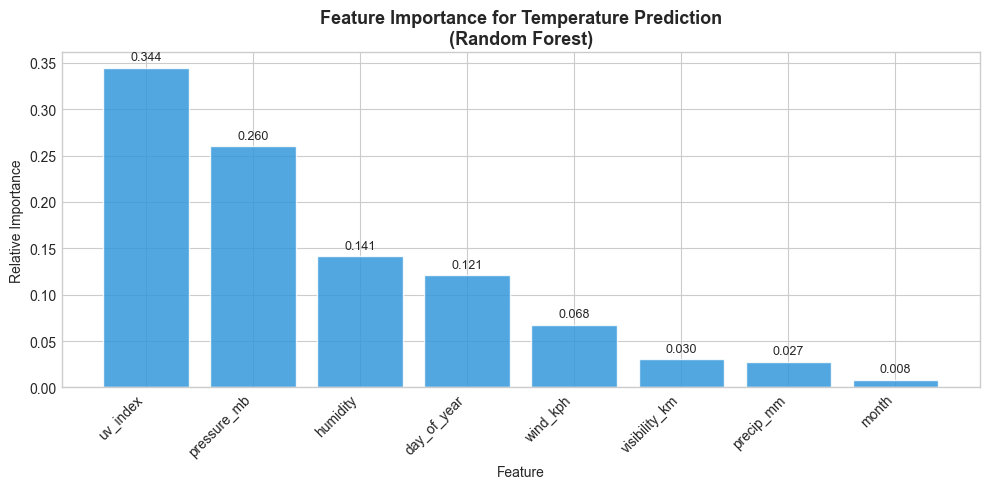


Feature Importance Ranking:
  1. uv_index: 0.3444 (34.4%)
  2. pressure_mb: 0.2599 (26.0%)
  3. humidity: 0.1414 (14.1%)
  4. day_of_year: 0.1208 (12.1%)
  5. wind_kph: 0.0677 (6.8%)
  6. visibility_km: 0.0303 (3.0%)
  7. precip_mm: 0.0273 (2.7%)
  8. month: 0.0082 (0.8%)


In [38]:
importances = rf_model.feature_importances_
feature_names = features_available

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(indices)), importances[indices],
               color='#3498db', alpha=0.85, edgecolor='white')
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance for Temperature Prediction\n(Random Forest)',
          fontsize=13, fontweight='bold')
plt.ylabel('Relative Importance')
plt.xlabel('Feature')

for bar, imp in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{imp:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
for i, idx in enumerate(indices):
    print(f'  {i+1}. {feature_names[idx]}: {importances[idx]:.4f} ({importances[idx]*100:.1f}%)')

### Time Series Analysis

This visualization shows the evolution of global average temperature over time, with moving averages to reveal underlying trends and reduce daily noise.

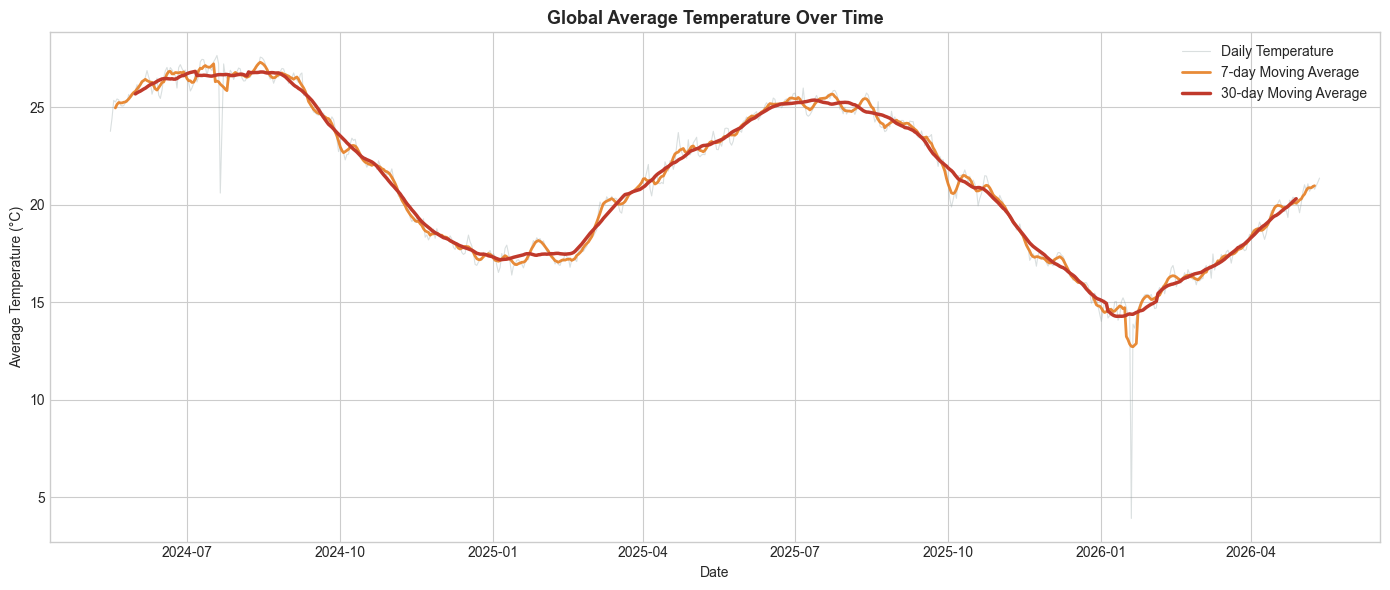

In [39]:
temp_daily = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean().reset_index()
temp_daily.columns = ['date', 'temperature']
temp_daily['date'] = pd.to_datetime(temp_daily['date'])
temp_daily = temp_daily.sort_values('date')

temp_daily['moving_avg_7d'] = temp_daily['temperature'].rolling(window=7, center=True).mean()
temp_daily['moving_avg_30d'] = temp_daily['temperature'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14, 6))
plt.plot(temp_daily['date'], temp_daily['temperature'],
         alpha=0.35, color='#95a5a6', linewidth=0.8, label='Daily Temperature')
plt.plot(temp_daily['date'], temp_daily['moving_avg_7d'],
         color='#e67e22', linewidth=2, label='7-day Moving Average', alpha=0.9)
plt.plot(temp_daily['date'], temp_daily['moving_avg_30d'],
         color='#c0392b', linewidth=2.5, label='30-day Moving Average')

plt.title('Global Average Temperature Over Time',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 8. Geographical Analysis & Regional Patterns

This section analyzes temperature variations across different countries, revealing which regions experience the coldest and warmest conditions globally.

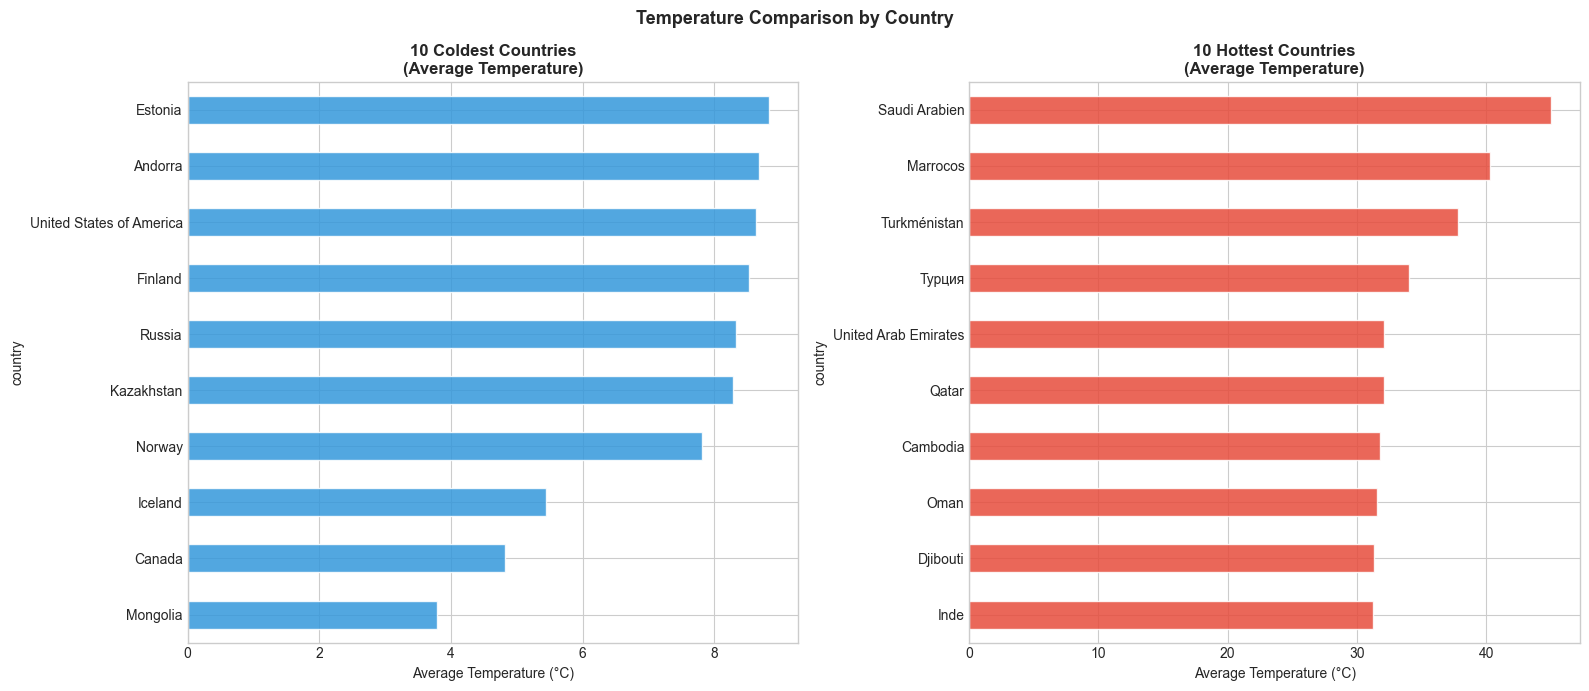

In [40]:
if 'country' in df.columns:
    temp_country = df.groupby('country')['temperature_celsius'].mean().sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    temp_country.head(10).plot(kind='barh', ax=axes[0], color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].set_title('10 Coldest Countries\n(Average Temperature)', fontweight='bold')
    axes[0].set_xlabel('Average Temperature (°C)')
    axes[0].axvline(0, color='black', linewidth=0.5)

    temp_country.tail(10).plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.85, edgecolor='white')
    axes[1].set_title('10 Hottest Countries\n(Average Temperature)', fontweight='bold')
    axes[1].set_xlabel('Average Temperature (°C)')

    plt.suptitle('Temperature Comparison by Country',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Key Findings & Conclusions

### Summary of Results

This comprehensive analysis of the Global Weather Repository dataset reveals important patterns in global temperature and weather conditions.

In [41]:
print('\n' + '='*60)
print('ANALYSIS SUMMARY')
print('='*60)

if 'country' in df.columns:
    print(f'\nGeographical Coverage:')
    print(f'  Countries analyzed: {df["country"].nunique()}')
if 'city' in df.columns:
    print(f'  Cities analyzed: {df["city"].nunique()}')

print(f'\nTemporal Coverage:')
print(f'  Date range: {df["last_updated"].min().date()} to {df["last_updated"].max().date()}')
print(f'  Total records: {len(df):,}')

print(f'\nTemperature Metrics:')
print(f'  Global average: {df["temperature_celsius"].mean():.1f}°C')
print(f'  Maximum recorded: {df["temperature_celsius"].max():.1f}°C')
print(f'  Minimum recorded: {df["temperature_celsius"].min():.1f}°C')

print(f'\nOther Weather Variables:')
print(f'  Average precipitation: {df["precip_mm"].mean():.1f} mm')
print(f'  Average wind speed: {df["wind_kph"].mean():.1f} km/h')
print(f'  Average humidity: {df["humidity"].mean():.1f}%')

print(f'\nBest Forecasting Model Performance (Random Forest):')
print(f'  R² Score: {metrics_rf["R2"]*100:.1f}% (explains variance in data)')
print(f'  Average Error: {metrics_rf["MAE"]:.2f}°C')
print(f'  Root Mean Squared Error: {metrics_rf["RMSE"]:.2f}°C')


ANALYSIS SUMMARY

Geographical Coverage:
  Countries analyzed: 211

Temporal Coverage:
  Date range: 2024-05-16 to 2026-05-12
  Total records: 140,923

Temperature Metrics:
  Global average: 21.2°C
  Maximum recorded: 79.3°C
  Minimum recorded: -29.8°C

Other Weather Variables:
  Average precipitation: 0.1 mm
  Average wind speed: 12.9 km/h
  Average humidity: 66.7%

Best Forecasting Model Performance (Random Forest):
  R² Score: 77.7% (explains variance in data)
  Average Error: 3.00°C
  Root Mean Squared Error: 4.54°C
